# TF_IDF Analysis

## Goal
TF-IDF is not just a formula - it is a way of thinking about text.
This notebook explores what TF-IDF actually sees in a a document
any why some words get higher scores then other.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

In [8]:
# Small corpus - easy to inspect
corpus = [
    "I love machine learning and NLP",
    "Machine learning is a subset of artificial intelligence",
    "NLP stands for Natural Language Preprocessing",
    "Deep learning is a subset of machine learning",
    "I love studying artificial intelligence"
]

# Fit TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)

# Convert to readable DataFrame
df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f"Doc {i+1}" for i in range(len(corpus))]
).round(3)

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"\nTF-IDF Matrix:")
print(df.T)

Vocabulary size: 17

TF-IDF Matrix:
               Doc 1  Doc 2  Doc 3  Doc 4  Doc 5
and            0.559  0.000  0.000  0.000  0.000
artificial     0.000  0.396  0.000  0.000  0.470
deep           0.000  0.000  0.000  0.439  0.000
for            0.000  0.000  0.421  0.000  0.000
intelligence   0.000  0.396  0.000  0.000  0.470
is             0.000  0.396  0.000  0.354  0.000
language       0.000  0.000  0.421  0.000  0.000
learning       0.374  0.329  0.000  0.588  0.000
love           0.451  0.000  0.000  0.000  0.470
machine        0.374  0.329  0.000  0.294  0.000
natural        0.000  0.000  0.421  0.000  0.000
nlp            0.451  0.000  0.339  0.000  0.000
of             0.000  0.396  0.000  0.354  0.000
preprocessing  0.000  0.000  0.421  0.000  0.000
stands         0.000  0.000  0.421  0.000  0.000
studying       0.000  0.000  0.000  0.000  0.582
subset         0.000  0.396  0.000  0.354  0.000


## 2. Visualize Top Words per Document
Which words does TF-IDF consider most important in each document?

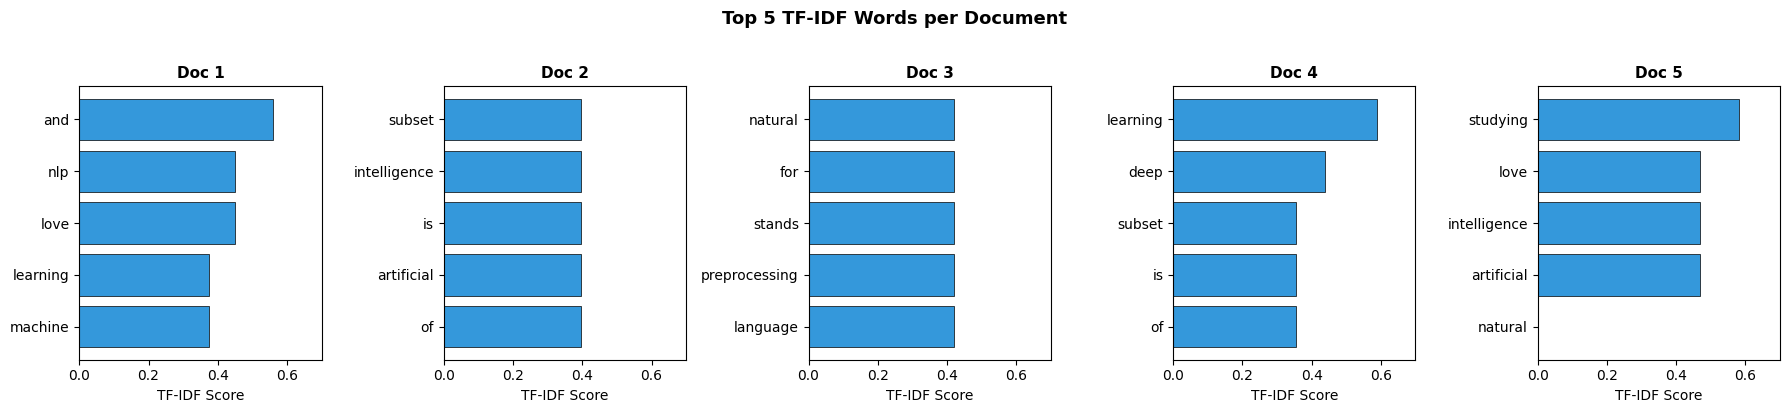

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, (doc_name, ax) in enumerate(zip(df.index, axes)):
    top = df.loc[doc_name].sort_values(ascending=False).head(5)
    ax.barh(top.index[::-1], top.values[::-1], color='#3498db', edgecolor='black', linewidth=0.5)
    ax.set_title(f"{doc_name}", fontsize=11, fontweight='bold')
    ax.set_xlabel('TF-IDF Score')
    ax.set_xlim(0, 0.7)

plt.suptitle('Top 5 TF-IDF Words per Document', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tfidf_per_doc.png', dpi=300)
plt.show()

## 3. Key Observations

| Document | Top Words | Why |
|----------|-----------|-----|
| Doc 1 | and, love, nlp, machine, learning | unique combination of topics |
| Doc 2 | machine, is, of, artificial, subset | describes ML as subset of AI |
| Doc 3 | for, stands, preprocessing, language, natural | NLP definition doc |
| Doc 4 | learning, deep, michine*, subset, is | deep learning focused |
| Doc 5 | studying, intelligence, love, artificial, and | personal interest doc |


## Key Insight
TF-IDF does not understand meaning.
"machine learning" and "deep learning" are completely unrelated in TF-IDF space
even though they share a strong semantic connection.
This is the fundamental limitation that word embeddings solve.

## Next
How do embeddings represent meaning in vector space?
-> 04_embeddings_visualization.ipynb